<a href="https://colab.research.google.com/github/ArpanUchicago/alpaca-py/blob/master/examples/crypto/crypto-btc-usd-swing-trade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<b>Note: This Jupyter Notebook is associated with the article [How to Trade BTC/USD on Alpaca and TradingView](https://alpaca.markets/learn/btc-usd-alpaca-tradingview).</b>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alpacahq/alpaca-py/blob/master/examples/crypto/crypto-btc-usd-swing-trade.ipynb)

# Step 1: Setting Up the Bitcoin Trading Environment

In [1]:
# Install or upgrade the package `alpaca-py` and import it
# !python3 -m pip install --upgrade alpaca-py
# Install or upgrade the package `pandas-ta`
# !python3 -m pip install -U git+https://github.com/twopirllc/pandas-ta

In [5]:
# Import standard library modules
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo

# Import third-party modules
import numpy as np
import pandas as pd
# Install or upgrade the package `pandas-ta`
!python3 -m pip install -U pandas-ta
import pandas_ta as ta  # The installment of pandas-ta may be tricky. Please find the pypi page here (https://pypi.org/project/pandas-ta/)
import matplotlib.pyplot as plt

# Import Alpaca modules
!python3 -m pip install --upgrade alpaca-py
import alpaca
from alpaca.data.historical.crypto import CryptoHistoricalDataClient
from alpaca.data.requests import (
    CryptoBarsRequest,
    CryptoLatestQuoteRequest,
    CryptoQuoteRequest,
    CryptoTradesRequest,
)
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from alpaca.trading.client import TradingClient
from alpaca.trading.enums import (
    AssetClass,
    AssetStatus,
    OrderSide,
    OrderType,
    QueryOrderStatus,
    TimeInForce,
)
from alpaca.trading.requests import LimitOrderRequest, MarketOrderRequest


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/122.5 kB 3.9 MB/s eta 0:00:00


In [6]:
# Please change the following to your own PAPER api key and secret
# You can get them from https://alpaca.markets/

API_KEY = "PKRU3HAOEJWLFWD2EQ2SBEKULK"
API_SECRET = "BrAtVCJDxyJGxBF94PpVku2XrNCEgZakg8y3SwJFSDdP"

#### We use paper environment for this example ####
PAPER = True # Please do not modify this. This example is for paper trading only.
####

# Below are the variables for development this documents
# Please do not change these variables
trade_api_url = None
trade_api_wss = None
data_api_url = None
stream_data_wss = None

# setup trading clients
trade_client = TradingClient(api_key=API_KEY, secret_key=API_SECRET, paper=PAPER, url_override=trade_api_url)
# setup crypto historical data client
crypto_historical_data_client = CryptoHistoricalDataClient(api_key=API_KEY, secret_key=API_SECRET)

# Step 2: Executing Market Data Analysis

In [7]:
# we will place orders which Alapca trading platform supports
# - order types for crypto: market, limit, stop_limit
# - time_in_force for crypto: gtc, ioc.
# please refer to the following documents for more details
# ref. https://docs.alpaca.markets/docs/orders-at-alpaca
# ref. https://docs.alpaca.markets/reference/postorder

# we will place orders for symbol: BTC/USD in this example
symbol = "BTC/USD"

In [8]:
# Set the timezone
timezone = ZoneInfo("America/New_York")

# Get current date in US/Eastern timezone
today = datetime.now(timezone).date()

# Define the start and end dates for the historical period
start_date = today - timedelta(days=365 * 2)
end_date = today - timedelta(days=1)

# Create the request object
req = CryptoBarsRequest(
    symbol_or_symbols = [symbol],
    timeframe=TimeFrame.Day,
    start=start_date,
    end_date=end_date,
)

bars_data = crypto_historical_data_client.get_crypto_bars(req).df.reset_index(level='symbol', drop=True)

In [9]:
# Create a copy of the dataframe to avoid modifying the original data.
df = bars_data.copy()
df.head()

,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,
2024-04-29 00:00:00+00:00,63087.622,64175.5150,61775.0350,63797.7575,2.514710,170.0,62549.533126
2024-04-30 00:00:00+00:00,63791.800,64688.8345,59099.5735,60593.6930,4.786206,272.0,60481.597214
2024-05-01 00:00:00+00:00,60634.715,60757.3500,56498.4400,58314.4810,30.099127,330.0,56876.928433
2024-05-02 00:00:00+00:00,58321.165,59608.2855,56908.4500,59109.0105,2.497791,175.0,58753.873920
2024-05-03 00:00:00+00:00,59112.790,63362.8710,58846.9000,62863.7000,2.062287,185.0,61359.895429


## Calculating EMA

In [10]:
# Define Exponential Moving Average (EMA) periods
short_window = 12 # Common short-term period
long_window = 26  # Common long-term period

# Calculate EMA using pandas.ewm()
# 'span' is related to the period N, often approximated as span = N for typical EMA calculations.
# 'adjust=False' uses a standard recursive formula common in technical analysis.
df["ema_short"] = df["close"].ewm(span=short_window, adjust=False).mean()
df["ema_long"] = df["close"].ewm(span=long_window, adjust=False).mean()


## Calculating SMA, ATR, and ADX

In [11]:
# Calculate Simple Moving Average (SMA) using rolling() with 50-day SMA
sma_window = 50
df["sma"] = df["close"].rolling(window=sma_window).mean()
df[["close", "sma"]].tail()

,close,sma
timestamp,,
2026-04-26 00:00:00+00:00,78662.640,71579.52748
2026-04-27 00:00:00+00:00,77363.501,71807.41069
2026-04-28 00:00:00+00:00,76320.193,71965.03465
2026-04-29 00:00:00+00:00,75756.385,72081.07269
2026-04-30 00:00:00+00:00,75651.957,72190.17969


In [12]:
# Calculate Average True Range (ATR) - requires high, low, close columns
# Default length is 14 periods
df.ta.atr(length=14, append=True) # Appends 'ATR_14' column

# Calculate Average Directional Index (ADX) - requires high, low, close
# Default length is 14 periods
# Note: ta.adx() returns ADX, Positive Directional Movement (DMP), and Negative Directional Movement (DMN)
df.ta.adx(length=14, append=True) # Appends 'ADX_14', 'DMP_14', 'DMN_14' columns

,ADX_14,ADXR_14_2,DMP_14,DMN_14
timestamp,,,,
2024-04-29 00:00:00+00:00,NaN,NaN,NaN,NaN
2024-04-30 00:00:00+00:00,NaN,NaN,NaN,NaN
2024-05-01 00:00:00+00:00,NaN,NaN,NaN,NaN
2024-05-02 00:00:00+00:00,NaN,NaN,NaN,NaN
2024-05-03 00:00:00+00:00,NaN,NaN,NaN,NaN
...,...,...,...,...
2026-04-26 00:00:00+00:00,26.021718,24.708837,29.258955,11.184725
2026-04-27 00:00:00+00:00,26.654511,25.620109,26.644646,12.863782
2026-04-28 00:00:00+00:00,26.683110,26.352414,25.168242,14.449661


## Visualizing Indicators

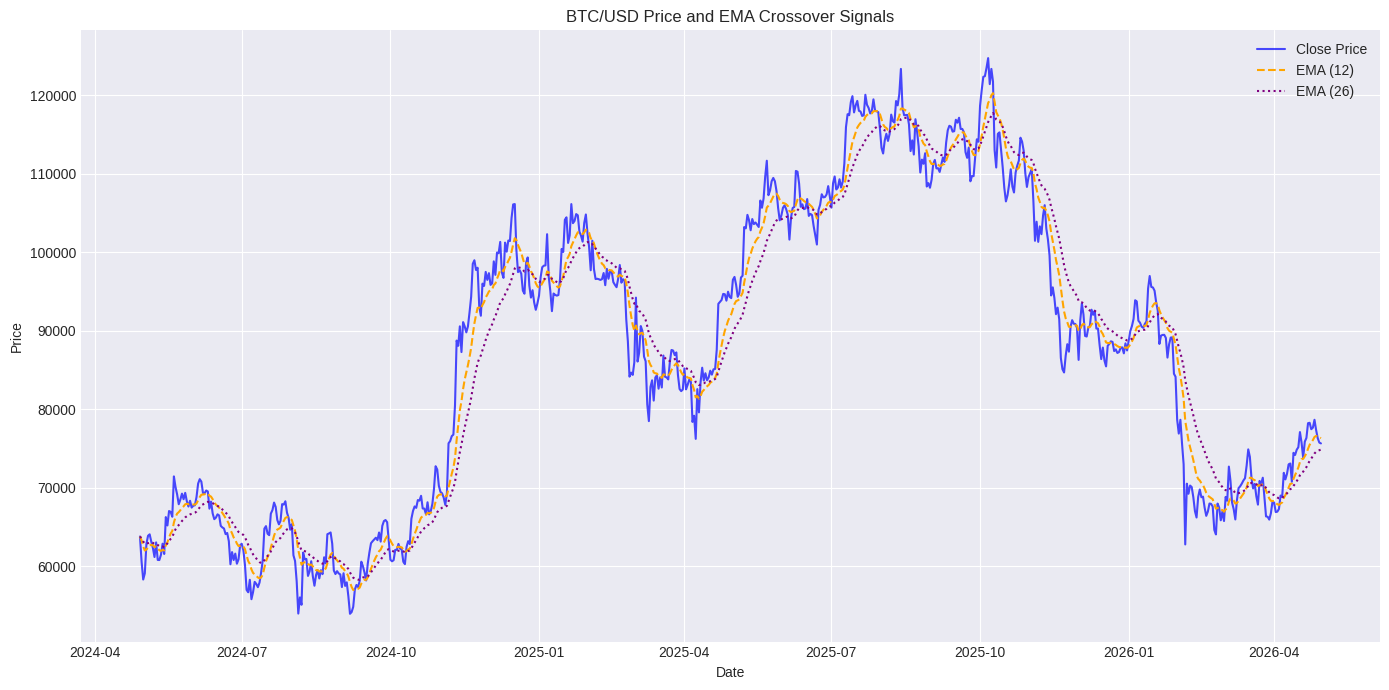

In [13]:
if not df.empty and "ema_short" in df.columns and "ema_long" in df.columns:
    plt.style.use("seaborn-v0_8-darkgrid") # Use a visually appealing style
    plt.figure(figsize=(14, 7))

    plt.plot(df.index, df["close"], label="Close Price", color="blue", alpha=0.7)
    plt.plot(df.index, df["ema_short"], label=f"EMA ({short_window})", color="orange", linestyle="--")
    plt.plot(df.index, df["ema_long"], label=f"EMA ({long_window})", color="purple", linestyle=":")

    # Optional: Add crossover points visually
    buy_signals = df[df["buy_signal"]] if "buy_signal" in df else pd.DataFrame()
    sell_signals = df[df["sell_signal"]] if "sell_signal" in df else pd.DataFrame()

    if not buy_signals.empty:
        plt.scatter(buy_signals.index, buy_signals["close"], label="Buy Signal", marker="^", color="green", s=100, zorder=5)
    if not sell_signals.empty:
        plt.scatter(sell_signals.index, sell_signals["close"], label="Sell Signal", marker="v", color="red", s=100, zorder=5)

    plt.title(f'{symbol} Price and EMA Crossover Signals')
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()
else:
    print("Cannot plot: DataFrame is empty or EMA columns are missing.")

# Step 3: Creating a Bitcoin Swing Trading Algorithm with EMAs

In [14]:
# Generate Buy Signal
# Condition 1: Is the short EMA currently above the long EMA?
currently_above = df["ema_short"] > df["ema_long"]
# Condition 2: Was the short EMA below or equal to the long EMA on the previous bar?
previously_below_or_equal = df["ema_short"].shift(1) <= df["ema_long"].shift(1)
# Buy Signal: True only on the bar where the crossover *just* happened
df["buy_signal"] = currently_above & previously_below_or_equal

# Generate Sell Signal
# Condition 1: Is the short EMA currently below the long EMA?
currently_below = df["ema_short"] < df["ema_long"]
# Condition 2: Was the short EMA above or equal to the long EMA on the previous bar?
previously_above_or_equal = df["ema_short"].shift(1) >= df["ema_long"].shift(1)
# Sell Signal: True only on the bar where the crossover *just* happened
df["sell_signal"] = currently_below & previously_above_or_equal

# Display rows where signals occurred
print("\nCrossover Signal Occurrences:")
signal_rows = df[df["buy_signal"] | df["sell_signal"]]
if not signal_rows.empty:
    print(signal_rows[["close", "ema_short", "ema_long", "buy_signal", "sell_signal"]])
else:
    print("No crossover signals found in the data.")



Crossover Signal Occurrences:
                                 close      ema_short       ema_long  \
timestamp                                                              
2024-04-30 00:00:00+00:00   60593.6930   63304.824500   63560.419389   
2024-05-16 00:00:00+00:00   65204.5500   63062.725126   62916.071538   
2024-06-16 00:00:00+00:00   66622.8350   67665.342454   67690.695920   
2024-07-18 00:00:00+00:00   63967.0655   61611.213766   61522.037758   
2024-08-04 00:00:00+00:00   58098.4080   63528.525604   63836.166201   
2024-08-24 00:00:00+00:00   64185.0170   60973.223577   60928.580610   
2024-08-28 00:00:00+00:00   59015.0550   60997.192320   61009.504149   
2024-09-18 00:00:00+00:00   61746.2600   59083.806450   58944.636465   
2024-12-29 00:00:00+00:00   93607.0750   96666.492676   96924.397997   
2025-01-05 00:00:00+00:00   98322.4200   96691.307555   96682.901591   
2025-01-09 00:00:00+00:00   92497.1035   96378.570466   96605.132741   
2025-01-16 00:00:00+00:00  100032

In [15]:
# Store the latest signal information for potential execution
latest_data = df.iloc[-1]
print("\nLatest Data Row:")
latest_data[['close', 'ema_short', 'ema_long', 'buy_signal', 'sell_signal']]


Latest Data Row:


,2026-04-30 00:00:00+00:00
close,75651.957
ema_short,76318.032826
ema_long,74859.128338
buy_signal,False
sell_signal,False


# Step 4: Purchasing BTC/USD using Python with Alpaca's Trading API

## Submitting Simple Market Orders

In [16]:
# simple, market order, notional
req = MarketOrderRequest(
    symbol = symbol,
    notional = 250,  # notional is specified in USD, here we specify $250
    side = OrderSide.BUY,
    type = OrderType.MARKET,
    time_in_force = TimeInForce.GTC,
)
res = trade_client.submit_order(req)
res

{   'asset_class': <AssetClass.CRYPTO: 'crypto'>,
    'asset_id': UUID('276e2673-764b-4ab6-a611-caf665ca6340'),
    'canceled_at': None,
    'client_order_id': '32976908-d2fb-4df1-8c76-8c550432df18',
    'created_at': datetime.datetime(2026, 4, 30, 0, 26, 32, 791759, tzinfo=TzInfo(0)),
    'expired_at': None,
    'expires_at': datetime.datetime(2026, 7, 28, 20, 0, tzinfo=TzInfo(0)),
    'extended_hours': False,
    'failed_at': None,
    'filled_at': None,
    'filled_avg_price': None,
    'filled_qty': '0',
    'hwm': None,
    'id': UUID('47770dd9-75dd-407f-8ef9-96f5ab8b082e'),
    'legs': None,
    'limit_price': None,
    'notional': '250',
    'order_class': <OrderClass.SIMPLE: 'simple'>,
    'order_type': <OrderType.MARKET: 'market'>,
    'position_intent': <PositionIntent.BUY_TO_OPEN: 'buy_to_open'>,
    'qty': None,
    'ratio_qty': None,
    'replaced_at': None,
    'replaced_by': None,
    'replaces': None,
    'side': <OrderSide.BUY: 'buy'>,
    'status': <OrderStatus.PENDIN

## Submitting Limit Order Requests

In [17]:
# Function to get latest quotes by symbol
def get_latest_quote(symbol):
    req = CryptoLatestQuoteRequest(symbol_or_symbols = [symbol])
    res = crypto_historical_data_client.get_crypto_latest_quote(req)
    return res

# Get latest quotes
btc_quote = get_latest_quote("BTC/USD")

In [18]:
# Get the estimated buying cost of BTC/USD with given qty
def calc_cost(quote, qty):
    # Calculate total cost of BTC/USD order and round to 4 decimal places
    total_cost = round(qty * quote[symbol].ask_price, 4)
    return total_cost

In [19]:
QTY = 0.003
cost = calc_cost(btc_quote, qty=QTY)
f"The total cost of BTC/USD order for qtry={QTY} is ${cost}"

'The total cost of BTC/USD order for qtry=0.003 is $227.4267'

In [20]:
# Define a 6% range around the crypto price
LIMIT_RANGE = 0.06

# Calculate the limit price as 6% below the current ask price
limit_price = btc_quote[symbol].ask_price * (1 - LIMIT_RANGE)
f"The limit price for BTC/USD 'BUY' order for qty={QTY} is ${limit_price}"

"The limit price for BTC/USD 'BUY' order for qty=0.003 is $71260.366"

In [21]:
# simple, market order, notional
req = LimitOrderRequest(
    symbol=symbol,
    qty=QTY,
    limit_price = limit_price,
    side=OrderSide.BUY,
    type = OrderType.LIMIT,
    time_in_force=TimeInForce.GTC, # TIF=DAY is not available
)

res = trade_client.submit_order(req)
res

{   'asset_class': <AssetClass.CRYPTO: 'crypto'>,
    'asset_id': UUID('276e2673-764b-4ab6-a611-caf665ca6340'),
    'canceled_at': None,
    'client_order_id': '03b4e4e0-bc11-4145-8f0d-d1d4e427cbbd',
    'created_at': datetime.datetime(2026, 4, 30, 0, 27, 2, 990246, tzinfo=TzInfo(0)),
    'expired_at': None,
    'expires_at': datetime.datetime(2026, 7, 28, 20, 0, tzinfo=TzInfo(0)),
    'extended_hours': False,
    'failed_at': None,
    'filled_at': None,
    'filled_avg_price': None,
    'filled_qty': '0',
    'hwm': None,
    'id': UUID('cb8ba78e-971b-4299-a218-99ab6c24c06f'),
    'legs': None,
    'limit_price': '71260.366',
    'notional': None,
    'order_class': <OrderClass.SIMPLE: 'simple'>,
    'order_type': <OrderType.LIMIT: 'limit'>,
    'position_intent': <PositionIntent.BUY_TO_OPEN: 'buy_to_open'>,
    'qty': '0.003',
    'ratio_qty': None,
    'replaced_at': None,
    'replaced_by': None,
    'replaces': None,
    'side': <OrderSide.BUY: 'buy'>,
    'status': <OrderStatus.